# Partitioning Method Comparison

This notebook inspects the metaparameter study results produced by `src/mqt/ionshuttler/multi_shuttler/main2.py`. It normalizes every entry stored in `outputs/simulation_results*.h5` and produces comparison plots between each partitioning strategy across all swept parameters (number of processing zones, ions per zone, grid size, MZ trap size, DAG compilation, and slice-plan enforcement).

Steps covered below:

1. Locate and select the HDF5 run summary you want to analyze.
2. Load it into a tidy pandas DataFrame with normalized partitioning metadata.
3. Use the helper utilities to summarize, visualize, and compare partitioning methods.


## Prerequisites

- Make sure the metaparameter study has been executed so that one or more `simulation_results*.h5` files exist inside `outputs/` (and optionally `outputs/archive/`).
- The notebook relies on `pandas`, `numpy`, `matplotlib`, and `h5py`. If any import fails, install the missing package inside the same environment that launches Jupyter (the project's virtual environment already contains these dependencies).
- Set `RESULTS_FILE` in the next section if you prefer a different results file than the default shown in the table.


In [12]:
from __future__ import annotations

import ast
import json
import os
from datetime import datetime
from pathlib import Path
from typing import Any

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

plt.style.use("tableau-colorblind10")


In [13]:
def find_project_root(marker: str = "pyproject.toml") -> Path:
    current = Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {marker} starting from {current}.")

PROJECT_ROOT = find_project_root()
OUTPUT_DIRS = [PROJECT_ROOT / "outputs/results"]

def list_result_files(pattern: str = "simulation_results*.h5") -> list[Path]:
    files: list[Path] = []
    for directory in OUTPUT_DIRS:
        if directory.exists():
            files.extend(sorted(directory.glob(pattern)))
    files.sort(key=lambda path: path.stat().st_mtime)
    return files

available_result_files = list_result_files()
file_records = []
for path in available_result_files:
    stat = path.stat()
    file_records.append(
        {
            "file": str(path.relative_to(PROJECT_ROOT)),
            "modified": datetime.fromtimestamp(stat.st_mtime).isoformat(timespec="seconds"),
            "size_kb": round(stat.st_size / 1024, 1),
        }
    )

files_df = pd.DataFrame(file_records)
display(files_df if not files_df.empty else "No simulation_results*.h5 files found yet.")


   

,file,modified,size_kb
0,outputs/results/simulation_results.h5,2025-11-10T15:05:40,355.9
1,outputs/results/simulation_results_random_nati...,2025-11-20T16:53:07,2230.0
2,outputs/results/simulation_results_grover-noan...,2025-11-21T12:38:29,93.0
3,outputs/results/simulation_results_random_inde...,2025-11-21T13:02:10,53.9
4,outputs/results/simulation_results_qpeexact_in...,2025-11-21T14:40:05,885.5
...,...,...,...
181,outputs/results/simulation_results_INSIDE_Benc...,2026-03-19T10:48:28,15.1
182,outputs/results/simulation_results_INSIDE_Benc...,2026-03-19T11:28:39,8.8
183,outputs/results/simulation_results_INSIDE_Benc...,2026-03-19T12:53:46,8.8
184,outputs/results/simulation_results_INSIDE_Benc...,2026-03-19T13:52:25,8.8


In [14]:
if available_result_files:
    print("Defaulting to the most recently modified file shown above.")
    RESULTS_FILE = available_result_files[-1]
else:
    RESULTS_FILE = PROJECT_ROOT / "outputs" / "simulation_results.h5"


name = "simulation_results_INSIDE_StabilityStudytest_dense_4_[8]pzs_[2]perpz_NODAG"


#RESULTS_FILE = PROJECT_ROOT / "outputs" / f"results/{name}.h5"

print(f"RESULTS_FILE = {RESULTS_FILE}")
print("Set RESULTS_FILE manually if you prefer a different file.")


Defaulting to the most recently modified file shown above.
RESULTS_FILE = /home/linus/code/ionshuttler/outputs/results/simulation_results_INSIDE_HyperStudy_test_inside_4pz_4_[4]pzs_[4]perpz_NODAG.h5
Set RESULTS_FILE manually if you prefer a different file.


## Data loading helpers

The following utilities normalize the HDF5 attributes into plain Python objects, decode the partitioning metadata, and create a tidy DataFrame that includes useful derived columns (such as `total_ions` or a human-readable `grid_label`).


In [15]:
COMPARISON_KEYS = ["grid_size", "mz_trap_size", "num_pzs", "ions_per_pz", "use_dag", "enforce_slice_plan", "algo_sigma", "algo_lookahead_weight_factor", "algo_balance_penalty", "algo_capacity_weight"]

def normalize_attr(value: Any) -> Any:
    if isinstance(value, bytes):
        return value.decode()
    if isinstance(value, np.generic):
        return value.item()
    return value

def _read_json_dataset(run_group: h5py.Group, name: str):
    if name not in run_group:
        return None
    raw = run_group[name][()]
    if isinstance(raw, bytes):
        raw = raw.decode()
    try:
        return json.loads(raw)
    except Exception:
        return None

def parse_partitioning_attr(raw_value: Any) -> dict[str, Any]:
    normalized = normalize_attr(raw_value)
    if normalized is None:
        return {"method": "none", "label": "none", "params": {}, "raw": normalized}
    if isinstance(normalized, str):
        text = normalized.strip()
        if text.lower() in {"none", "null", ""}:
            return {"method": "none", "label": "none", "params": {}, "raw": normalized}
        try:
            parsed = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            parsed = text
    else:
        parsed = normalized

    if isinstance(parsed, dict):
        method = parsed.get("name") or parsed.get("method") or "custom"
        params = parsed.get("params", {})
    else:
        method = str(parsed)
        params = {}

    label = method
    if params:
        param_str = ", ".join(f"{key}={params[key]}" for key in sorted(params))
        label = f"{method} ({param_str})"

    return {"method": method, "label": label, "params": params, "raw": normalized}

def load_results(file_path: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    path = Path(file_path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"{path} does not exist.")
    records: list[dict[str, Any]] = []
    with h5py.File(path, "r") as handle:
        if "results" not in handle:
            raise KeyError(f"No 'results' group found in {path}.")
        file_metadata = {key: normalize_attr(value) for key, value in handle.attrs.items()}
        for run_name, run_group in handle["results"].items():
            attrs = {key: normalize_attr(value) for key, value in run_group.attrs.items()}
            entry: dict[str, Any] = {"run_name": run_name, **attrs}
            partition_info = parse_partitioning_attr(entry.pop("partitioning_algorithm", "none"))
            try:
                entry["partition_method"] = partition_info["method"]
                entry["partition_variant"] = partition_info["label"]
                entry["partition_params"] = partition_info["params"]
                entry["source_file"] = str(path.relative_to(PROJECT_ROOT))
                entry["total_capacity"] = entry["num_pzs"] * entry["ions_per_pz"]
                entry["grid_label"] = f"{entry['grid_size']}x{entry['grid_size']}"
            except Exception:
                pass
            time_slices = _read_json_dataset(run_group, "time_slices")
            
            if time_slices is not None:
                entry["time_slices"] = time_slices
            qubit_assignments = _read_json_dataset(run_group, "qubit_assignments")
            if qubit_assignments is not None:
                entry["qubit_assignments"] = qubit_assignments
            records.append(entry)

    df = pd.DataFrame(records).sort_values("run_name").reset_index(drop=True)
    bool_columns = ["success", "use_dag", "enforce_slice_plan"]
    for column in bool_columns:
        if column in df.columns:
            df[column] = df[column].astype(bool)
    return df, file_metadata



In [16]:
results_df, file_metadata = load_results(RESULTS_FILE)
#print("File metadata:")
#print(json.dumps(file_metadata, indent=2))
print(f"Loaded {len(results_df)} runs from {RESULTS_FILE}.")
#results_df.head()


Loaded 144 runs from /home/linus/code/ionshuttler/outputs/results/simulation_results_INSIDE_HyperStudy_test_inside_4pz_4_[4]pzs_[4]perpz_NODAG.h5.


In [17]:
success_df = results_df[results_df["success"]].copy()
print(f"{len(success_df)} successful runs ({len(results_df) - len(success_df)} failures dropped).")
print("Runs per partitioning method:")
display(success_df["partition_method"].value_counts().to_frame(name="count"))
success_df.head()
print("algorithm_names", results_df["algorithm_name"].unique())
print("algo_capacity_weights", results_df["algo_capacity_weight"].unique())
print("num_ions", results_df["num_ions"].unique())

144 successful runs (0 failures dropped).
Runs per partitioning method:


,count
partition_method,
fgp_tabu_global_2,144


algorithm_names ['qft_nativegates_quantinuum_qiskit_opt2'
 'qaoa_nativegates_quantinuum_opt2'
 'qpeexact_nativegates_quantinuum_qiskit_opt2'
 'random_nativegates_quantinuum_qiskit_opt2']
algo_capacity_weights [0.1  0.15 0.2  0.25]
num_ions [30]


In [18]:
from collections.abc import Mapping


def _normalize_val(v):
    if isinstance(v, np.ndarray):
        v_list = v.tolist()
    elif isinstance(v, list):
        v_list = v
    else:
        return v
    if len(v_list) == 2:
        num, den = v_list
        return float(num)
    return tuple(v_list)


def _normalize_filters(filt: Mapping[str, Any] | None) -> dict[str, Any]:
    if not filt:
        return {}
    return {k: _normalize_val(v) for k, v in filt.items()}


def _normalize_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    if column in df.columns:
        df[column] = df[column].map(_normalize_val)
    return df


def apply_filters(df: pd.DataFrame, filters: Mapping[str, Any] | None = None) -> pd.DataFrame:
    filters = _normalize_filters(filters)
    if not filters:
        return df
    filtered = df.copy()
    for key, value in filters.items():
        if key not in filtered.columns:
            continue
        if isinstance(value, (list, tuple, set)):
            mask = filtered[key].isin(value) | filtered[key].isna()
        else:
            mask = (filtered[key] == value) | filtered[key].isna()
        filtered = filtered[mask]
    return filtered



def summarize_metric(
    df: pd.DataFrame,
    metric: str,
    varying_param: str,
    method_col: str = "partition_method",
    agg: str = "median",
    filters: Mapping[str, Any] | None = None,
) -> pd.DataFrame:
    filtered = apply_filters(df, filters)
    if filtered.empty:
        return pd.DataFrame()
    filtered = filtered.copy()
    _normalize_column(filtered, varying_param)
    _normalize_column(filtered, method_col)
    grouped = filtered.groupby([varying_param, method_col])[metric]
    summary = grouped.agg(["count", "mean", "median", "min", "max", "std"]).reset_index()
    if agg not in summary.columns:
        raise ValueError(f"Unsupported aggregation '{agg}'. Available columns: {summary.columns.tolist()}.")
    return summary


def sort_param_values(values: pd.Series) -> list[Any]:
    uniques = pd.unique(values)
    try:
        return sorted(uniques)
    except TypeError:
        return sorted(uniques, key=lambda item: str(item))
    


In [19]:
from collections.abc import Mapping

def _normalize_filters(filt: Mapping[str, Any] | None) -> dict[str, Any]:
    if not filt:
        return {}
    return {k: _normalize_val(v) for k, v in filt.items()}


def _normalize_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    if column in df.columns:
        df[column] = df[column].map(_normalize_val)
    return df


def apply_filters(df: pd.DataFrame, filters: Mapping[str, Any] | None = None) -> pd.DataFrame:
    filters = _normalize_filters(filters)
    if not filters:
        return df
    filtered = df.copy()
    for key, value in filters.items():
        if key not in filtered.columns:
            continue
        if isinstance(value, (list, tuple, set)):
            mask = filtered[key].isin(value) | filtered[key].isna()
        else:
            mask = (filtered[key] == value) | filtered[key].isna()
        filtered = filtered[mask]
    return filtered


def summarize_metric(
    df: pd.DataFrame,
    metric: str,
    varying_param: str,
    method_col: str = "partition_method",
    agg: str = "median",
    filters: Mapping[str, Any] | None = None,
) -> pd.DataFrame:
    filtered = apply_filters(df, filters)
    if filtered.empty:
        return pd.DataFrame()
    filtered = filtered.copy()
    _normalize_column(filtered, varying_param)
    _normalize_column(filtered, method_col)
    grouped = filtered.groupby([varying_param, method_col])[metric]
    summary = grouped.agg(["count", "mean", "median", "min", "max", "std"]).reset_index()
    if agg not in summary.columns:
        raise ValueError(f"Unsupported aggregation '{agg}'. Available columns: {summary.columns.tolist()}.")
    return summary


def sort_param_values(values: pd.Series) -> list[Any]:
    uniques = pd.unique(values)
    try:
        return sorted(uniques)
    except TypeError:
        return sorted(uniques, key=lambda item: str(item))


def plot_metric_by_param(
    df: pd.DataFrame,
    metric: str,
    varying_param: str,
    method_col: str = "partition_method",
    agg: str = "mean",
    plot_std: bool = True,
    filters: Mapping[str, Any] | None = None,
    param_combinations: Mapping[str, Mapping[str, Any]] | None = None,
    plot_cost_ratio: bool = True,
    plot_move_distance: bool = False,
) -> tuple[plt.Figure, plt.Axes] | None:
    def summarize_combination(label: str, combo_filters: Mapping[str, Any] | None):
        combined_filters = {**_normalize_filters(filters), **_normalize_filters(combo_filters)}
        filtered_combo = apply_filters(df, combined_filters)
        if filtered_combo.empty:
            return None
        filtered_combo = filtered_combo.copy()
        _normalize_column(filtered_combo, varying_param)
        grouped = filtered_combo.groupby(varying_param)[metric]
        summary = grouped.agg(["count", "mean", "median", "min", "max", "std"]).reset_index()
        if agg not in summary.columns:
            raise ValueError(
                f"Unsupported aggregation '{agg}'. Available columns: {summary.columns.tolist()}."
            )
        summary = summary.rename(columns={agg: metric})
        summary["line_label"] = label
        return summary

    label_context_df = None
    color_map: dict[str, str] = {}
    style_map: dict[str, str] = {}
    label_filters_map: dict[str, Mapping[str, Any]] = {}
    if param_combinations:
        plot_segments: list[pd.DataFrame] = []
        for label, combo_filters in param_combinations.items():
            combo_color = None
            combo_style = None
            combo_filters_copy = None
            if isinstance(combo_filters, Mapping):
                combo_filters_copy = dict(combo_filters)
                if "color" in combo_filters_copy:
                    combo_color = combo_filters_copy.pop("color")
                if "linestyle" in combo_filters_copy:
                    combo_style = combo_filters_copy.pop("linestyle")
            elif isinstance(combo_filters, tuple):
                combo_filters_copy = combo_filters[0]
                if len(combo_filters) >= 2:
                    combo_color = combo_filters[1]
                if len(combo_filters) >= 3:
                    combo_style = combo_filters[2]
            summary = summarize_combination(label, combo_filters_copy)
            if summary is not None:
                plot_segments.append(summary)
                if combo_color:
                    color_map[str(label)] = combo_color
                if combo_style:
                    style_map[str(label)] = combo_style
                if combo_filters_copy is not None:
                    label_filters_map[str(label)] = combo_filters_copy
        if not plot_segments:
            return None
        plot_df = pd.concat(plot_segments, ignore_index=True)
    else:
        filtered = apply_filters(df, filters)
        if filtered.empty:
            return None
        filtered = filtered.copy()
        _normalize_column(filtered, varying_param)
        summary = summarize_metric(filtered, metric, varying_param, method_col, agg, filters=None)
        if summary.empty:
            return None
        plot_df = summary[[varying_param, method_col, agg, "std"]].rename(
            columns={agg: metric, method_col: "line_label"}
        )
        label_context_df = filtered

    plot_df = plot_df.copy()
    _normalize_column(plot_df, varying_param)
    is_bool_param = plot_df[varying_param].dtype == bool
    if is_bool_param:
        plot_df[varying_param] = plot_df[varying_param].map({True: "True", False: "False"})
    order = sort_param_values(plot_df[varying_param])
    plot_df[varying_param] = pd.Categorical(plot_df[varying_param], categories=order, ordered=True)
    plot_df["_var_numeric"] = pd.to_numeric(plot_df[varying_param], errors="coerce")
    has_numeric_axis = plot_df["_var_numeric"].notna().all() and not is_bool_param
    plot_df = plot_df.sort_values([varying_param, "line_label"])

    def get_display_name(line_label: str) -> str:
        if param_combinations:
            return line_label
        if str(line_label) != "none":
            return line_label
        use_dag_val = None
        if label_context_df is not None and "use_dag" in label_context_df:
            vals = label_context_df["use_dag"].dropna().unique()
            if len(vals) == 1:
                use_dag_val = bool(vals[0])
        if use_dag_val is True:
            return "vanilla DAG"
        if use_dag_val is False:
            return "vanilla static partition"
        return "vanilla"

    def compute_move_distance(label: str):
        if "move_distance_total" not in df.columns:
            return None
        base_filters = _normalize_filters(filters)
        extra_filters = _normalize_filters(label_filters_map.get(label, {}))
        combined_filters = {**base_filters, **extra_filters}
        subset = apply_filters(df, combined_filters)
        if subset.empty or "move_distance_total" not in subset:
            return None
        subset = subset.copy()
        subset = subset.dropna(subset=["move_distance_total"])
        if subset.empty:
            return None
        _normalize_column(subset, varying_param)
        dist_summary = subset.groupby(varying_param)["move_distance_total"].mean().reset_index()
        if dist_summary.empty:
            return None
        dist_summary["_var_numeric"] = pd.to_numeric(dist_summary[varying_param], errors="coerce")
        return dist_summary

    def compute_cost_ratio(label: str):
        if not plot_cost_ratio:
            return None
        if "timestep" not in metric:
            return None
        if "cost_after" not in df.columns or "cost_before" not in df.columns:
            return None
        base_filters = _normalize_filters(filters)
        extra_filters = _normalize_filters(label_filters_map.get(label, {}))
        combined_filters = {**base_filters, **extra_filters}
        subset = apply_filters(df, combined_filters)
        if subset.empty:
            return None
        subset = subset.copy()
        if "cost_after" not in subset or "cost_before" not in subset:
            return None
        subset["cost_ratio"] = subset.apply(
            lambda row: (row["cost_after"] / row["cost_before"]) if row.get("cost_before") not in (0, None) and row.get("cost_after") not in (0, None) else None,
            axis=1,
        )
        subset = subset.dropna(subset=["cost_ratio"])
        subset = subset[(subset["cost_after"] != 0) & (subset["cost_before"] != 0)]
        if subset.empty:
            return None
        _normalize_column(subset, varying_param)
        ratio_summary = subset.groupby(varying_param)["cost_ratio"].mean().reset_index()
        if ratio_summary.empty:
            return None
        ratio_summary["_var_numeric"] = pd.to_numeric(ratio_summary[varying_param], errors="coerce")
        return ratio_summary

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = None
    i = 0
    colors = [
        "darkviolet",
        "darkorange",
        "royalblue",
        "gold",
        "forestgreen",
        "lightgreen",
        "plum",
        "",
        "",
        "",
        "",
        "",
        "",
        "",
    ]
    for label, group_df in plot_df.groupby("line_label"):
        label = str(label)
        group_df = group_df.sort_values(varying_param)
        if has_numeric_axis:
            x_vals = group_df["_var_numeric"]
        else:
            x_vals = group_df[varying_param].astype(str)
        display_label = get_display_name(label)
        line_color = color_map.get(label, colors[i])
        line_style = style_map.get(label, "-")
        line = ax.plot(x_vals, group_df[metric], marker="o", label=display_label, linestyle=line_style, color=line_color)[0]
        if plot_std and "std" in group_df:
            ax.errorbar(
                x_vals,
                group_df[metric],
                yerr=group_df["std"],
                fmt="none",
                capsize=5,
                capthick=1,
                alpha=0.7,
                color=line.get_color(),
            )

        #ratio_df = compute_cost_ratio(label)
        #rx = None
        #if ratio_df is not None:
        #    rx = ratio_df["_var_numeric"] if has_numeric_axis else ratio_df[varying_param].astype(str)
        #if ratio_df is not None:
        #    if ax2 is None:
        #        ax2 = ax.twinx()
        #        ax2.set_ylabel("mean cost_after / cost_before")
        #    ax2.plot(rx, ratio_df["cost_ratio"], linestyle=":", color=line.get_color(), alpha=0.6)
        #if ratio_df is not None:
        #    if ax2 is None:
        #        ax2 = ax.twinx()
        #        ax2.set_ylabel("mean cost_after / cost_before")
        #    rx = ratio_df["_var_numeric"] if has_numeric_axis else ratio_df[varying_param].astype(str)
        #    ax2.plot(rx, ratio_df["cost_ratio"], linestyle=":", color=line.get_color(), alpha=0.6)


        if plot_move_distance:
            dist_df = compute_move_distance(label)
            dx = None
            if dist_df is not None:
                dx = dist_df["_var_numeric"] if has_numeric_axis else dist_df[varying_param].astype(str)
            
            if dist_df is not None:
                if ax2 is None:
                    ax2 = ax.twinx()
                    ax2.set_ylabel("move distance total")
                ax2.plot(dx, dist_df["move_distance_total"], linestyle="--", color=line.get_color(), alpha=0.5)

            dist_df = compute_move_distance(label)
            if dist_df is not None:
                if ax2 is None:
                    ax2 = ax.twinx()
                dx = dist_df["_var_numeric"] if has_numeric_axis else dist_df[varying_param].astype(str)
                ax2.plot(dx, dist_df["move_distance_total"], linestyle="--", color=line.get_color(), alpha=0.5)

                #if ax2 is None:
                #    ax2 = ax.twinx()
                #    ax2.set_ylabel("mean cost_after / cost_before")
                #rx = ratio_df["_var_numeric"] if has_numeric_axis else ratio_df[varying_param].astype(str)
                #ax2.plot(rx, ratio_df["cost_ratio"], linestyle=":", color=line.get_color(), alpha=0.6)
            i = i + 1

    ax.set_xlabel(varying_param.replace("_", " ").replace("num", "#"))
    ax.set_ylabel(f"{agg} {metric.replace('_', ' ')}")
    title = f"{metric.replace('_', ' ')} vs {varying_param.replace('_', ' ')}"
    if filters:
        filter_desc = ", ".join(f"{key}={value}" for key, value in filters.items())
        title += f" (Filters: {filter_desc})"
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    fig.tight_layout()
    return fig, ax



print("algo_max_iterations_factor", success_df["algo_max_iterations_factor"].unique())
print("num_ions", success_df["num_ions"].unique())
print(success_df.keys())

algo_max_iterations_factor [ 25  50 100]
num_ions [30]
Index(['run_name', 'algo_balance_penalty', 'algo_candidate_list_length', 'algo_capacity_weight',
       'algo_distance_weight_factor', 'algo_enable_plots', 'algo_max_iterations_factor', 'algo_per_slice_quota',
       'algo_randomize_initial', 'algo_refresh_every', 'algo_relaxed_layering', 'algo_seed', 'algo_slack_dropoff',
       'algo_tabu_list_length', 'algorithm_name', 'cost_after', 'cost_before', 'cpu_time_seconds',
       'enable_memory_zone_manager', 'enforce_slice_plan', 'final_timesteps', 'gate_count_1q', 'gate_count_2q',
       'grid_size', 'ions_per_pz', 'move_distance_total', 'mz_trap_size', 'num_ions', 'num_pzs', 'optimize_params',
       'plot', 'save', 'success', 'timesteps_lower_bound', 'use_dag', 'partition_method', 'partition_variant',
       'partition_params', 'source_file', 'total_capacity', 'grid_label', 'time_slices', 'qubit_assignments'],
      dtype='object')


plotting with params {'num_ions': 30, 'algorithm_name': 'qft_nativegates_quantinuum_qiskit_opt2'} over algo_capacity_weight
Base filter matches 36 runs
Using 19 parameter combinations
Saved: ../outputs/plots/final_timesteps_by_algo_capacity_weight_num_ions_30_algorithm_name_qft_nativegates_quantinuum_qiskit_opt2_with_iterfactor.png


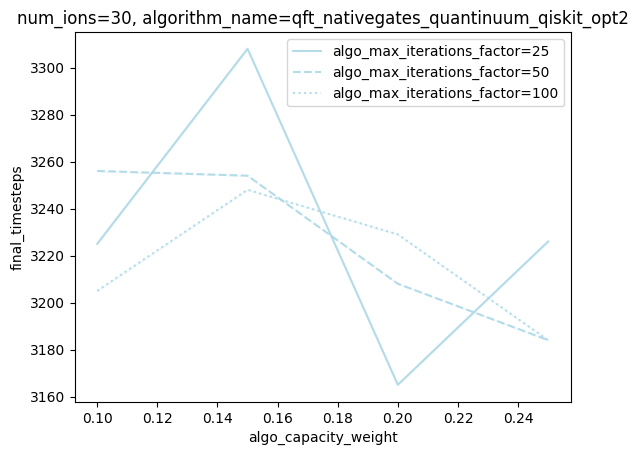

plotting with params {'num_ions': 30, 'algorithm_name': 'qaoa_nativegates_quantinuum_opt2'} over algo_capacity_weight
Base filter matches 36 runs
Using 19 parameter combinations
Saved: ../outputs/plots/final_timesteps_by_algo_capacity_weight_num_ions_30_algorithm_name_qaoa_nativegates_quantinuum_opt2_with_iterfactor.png


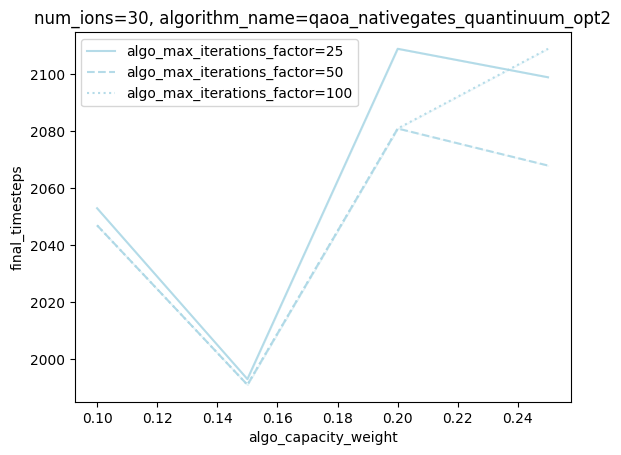

plotting with params {'num_ions': 30, 'algorithm_name': 'qpeexact_nativegates_quantinuum_qiskit_opt2'} over algo_capacity_weight
Base filter matches 36 runs
Using 19 parameter combinations
Saved: ../outputs/plots/final_timesteps_by_algo_capacity_weight_num_ions_30_algorithm_name_qpeexact_nativegates_quantinuum_qiskit_opt2_with_iterfactor.png


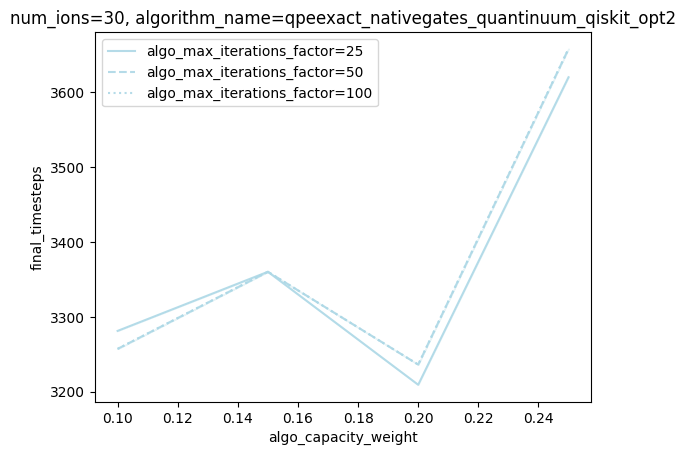

plotting with params {'num_ions': 30, 'algorithm_name': 'random_nativegates_quantinuum_qiskit_opt2'} over algo_capacity_weight
Base filter matches 36 runs
Using 19 parameter combinations
Saved: ../outputs/plots/final_timesteps_by_algo_capacity_weight_num_ions_30_algorithm_name_random_nativegates_quantinuum_qiskit_opt2_with_iterfactor.png


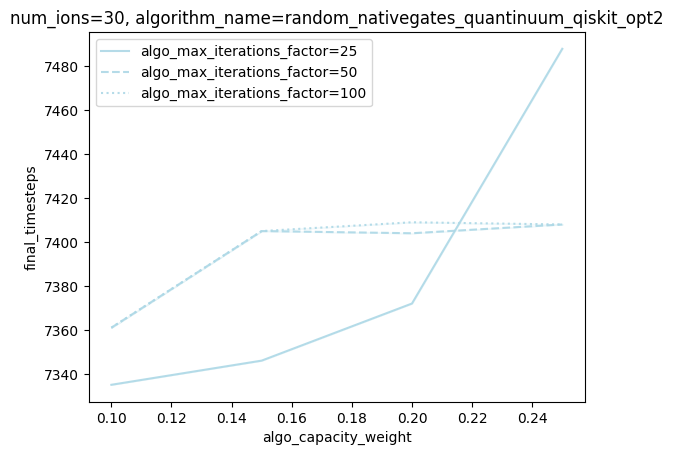

In [32]:

#parameters_to_sweep = ["num_ions"]
parameters_to_sweep = ["algo_capacity_weight"]
#parameters_to_sweep = ["num_ions", "grid_size", "num_pzs", "algo_sigma"]#, "algo_lookahead_weight_factor", "algo_balance_penalty"]
#parameters_to_sweep = ["num_ions", "grid_size", "num_pzs", "mz_trap_size"]
#parameters_to_sweep = [ "algo_distance_weight_factor",  "algo_capacity_weight", "algo_balance_penalty"]

# Define fixed parameters for filtering

fixed_params = {"num_ions" : 30}#"algo_capacity_weight": 0.5}#"num_ions" : 10}#"num_pzs": 2}
#fixed_params = {"num_pzs": 4, "ions_per_pz": 3,  "num_ions": 20, "enable_memory_zone_manager": False}
#fixed_params = {"num_pzs": 2}#"algo_max_iterations" : 1000}

specific_param_combinations = {
    "Static KL Part. + schedule" : {"color": "darkgray", "linestyle" : "-", "partition_method": "none", "use_dag": False,  "enable_memory_zone_manager": False},
    "Static KL Part. + schedule rehome" : {"color": "black", "linestyle" : "-", "partition_method": "rehome", "use_dag": False,  "enable_memory_zone_manager": False},
    "Static KL Part. + DAG" : {"color" : "black", "linestyle" : "-", "partition_method": "none", "use_dag": True,  "enable_memory_zone_manager": False},
    #"FGP Tabu (enforced)" : {"color" : "pink", "partition_method": "fgp_tabu_global", "enforce_slice_plan": True, "use_dag": False},
    #"Dyn Tabu Part. + schedule" : {"color" : "violet", "linestyle" : "-", "partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, "algo_candidate_list_length" : "None"},# "algo_max_iterations": 0},
    #"Dyn Tabu Part. + schedule" : {"color" : "darkblue", "linestyle" : "-", "partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False},
    #"FGP_tabu_global 2" : {"color" : "red", "linestyle" : "-", "partition_method": "fgp_tabu_global_2", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False},
    #"Dyn Tabu Part. + schedule 3" : {"color" : "lightblue", "linestyle" : "-", "partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, "algo_per_slice_quota": 1},
    "Dyn Tabu Part. + schedule + MZM" : {"color" : "violet","linestyle" : "--","partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False, "enable_memory_zone_manager": True},
    "Dyn Tabu Part. + DAG" : {"color" : "darkviolet","linestyle" : "-","partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": True,  "enable_memory_zone_manager": False, "optimize_params": False},
    "Dyn Tabu Part. + DAG (opt)" : {"color" : "magenta","linestyle" : "-","partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": True,  "enable_memory_zone_manager": False, "optimize_params": True},
    "Dyn Tabu Part. + DAG + MZM" : {"color" : "darkviolet","linestyle" : "--","partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": True, "enable_memory_zone_manager": True},
    "Dyn KL Part. + schedule" : {"color" : "limegreen", "linestyle" : "-", "partition_method": "fgp_kl", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False},
    "Dyn KL Part. + schedule + MZM" : {"color" : "limegreen", "linestyle" : "--", "partition_method": "fgp_kl", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": True},
    "Dyn KL Part. + DAG" : {"color" : "forestgreen", "linestyle" : "-", "partition_method": "fgp_kl", "enforce_slice_plan": False, "use_dag": True,  "enable_memory_zone_manager": False},
    "Dyn KL Part. + DAG + MZM" : {"color" : "forestgreen", "linestyle" : "--", "partition_method": "fgp_kl", "enforce_slice_plan": False, "use_dag": True,  "enable_memory_zone_manager": True},
    "Dyn rOEE Part. + schedule" : {"color" : "bisque", "linestyle" : "-", "partition_method": "fgp_roee", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False},
    "Dyn rOEE Part. + schedule + MZM" : {"color" : "bisque", "linestyle" : "--", "partition_method": "fgp_roee", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": True},
    "Dyn rOEE Part. + DAG" : {"color" : "darkorange", "linestyle" : "-", "partition_method": "fgp_roee", "enforce_slice_plan": False, "use_dag": True,  "enable_memory_zone_manager": False},
    "Dyn rOEE Part. + DAG + MZM" : {"color" : "darkorange", "linestyle" : "--", "partition_method": "fgp_roee", "enforce_slice_plan": False, "use_dag": True,  "enable_memory_zone_manager": True},
    #"Dyn Tabu Part. + schedule 2" : {"color" : "green", "linestyle" : "-", "partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, "algo_candidate_list_length" : 392},# "algo_max_iterations": 0},
    #"Dyn Tabu Part. + schedule 3" : {"color" : "blue", "linestyle" : "-", "partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, "algo_per_slice_quota" : 2, "algo_candidate_list_length" : 100},# "algo_max_iterations": 0},
    "FGP Tabu Global" : {"color" : "yellow", "linestyle" : "-", "partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, 'algo_relaxed_layering': False},
    "FGP Tabu Global relaxed" : {"color" : "orange", "linestyle" : "-", "partition_method": "fgp_tabu_global", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, 'algo_relaxed_layering': True},
    "FGP_tabu_global 2" : {"color" : "lightblue", "linestyle" : "-", "partition_method": "fgp_tabu_global_2", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, 'algo_relaxed_layering': False},
    "FGP_tabu_global 2 relaxed" : {"color" : "blue", "linestyle" : "-", "partition_method": "fgp_tabu_global_2", "enforce_slice_plan": False, "use_dag": False,  "enable_memory_zone_manager": False, 'algo_relaxed_layering': True},


}   


def plot_metric_by_param_multi(
    df,
    metric,
    varying_param,
    group_cols,
    filters=None,
    param_combinations=None,
    plot_std=False,
    subgroup_col="algo_max_iterations_factor",  # <- generic
):
    import matplotlib.pyplot as plt
    import numpy as np

    # Apply filters
    if filters:
        df = apply_filters(df, filters)

    if df.empty:
        return None

    # ----------- GROUPING -----------
    grouped = df.groupby(group_cols + [varying_param])[metric]
    mean_df = grouped.mean().reset_index()

    if plot_std:
        std_df = grouped.std().reset_index()
        merged = mean_df.merge(
            std_df,
            on=group_cols + [varying_param],
            suffixes=("_mean", "_std"),
        )
    else:
        merged = mean_df
        merged[f"{metric}_std"] = 0.0

    fig, ax = plt.subplots()

    unique_groups = merged[group_cols].drop_duplicates()

    # ----------- SUBGROUP STYLES (GENERIC) -----------
    sub_linestyles = ["-", "--", ":", "-.", (0, (3, 1, 1, 1))]

    unique_subgroups = sorted(df[subgroup_col].dropna().unique())
    substyle_map = {
        val: sub_linestyles[i % len(sub_linestyles)]
        for i, val in enumerate(unique_subgroups)
    }

    # ----------- MAIN LOOP -----------
    for _, group_vals in unique_groups.iterrows():
        mask = np.ones(len(merged), dtype=bool)

        for col in group_cols:
            mask &= merged[col] == group_vals[col]

        subset = merged[mask].sort_values(by=varying_param)

        if subset.empty:
            continue

        # ----------- STYLE MATCHING (ROBUST) -----------
        style = {}

        if param_combinations:
            for label, combo in param_combinations.items():
                match = True
                for key, value in combo.items():
                    if key in subset.columns:
                        if not (subset[key] == value).all():
                            match = False
                            break
                if match:
                    style = combo
                    break

        # Fallback color if nothing matches
        color = style.get("color", None)

        # ----------- SUBGROUP STYLE -----------
        subgroup_val = group_vals[subgroup_col]
        linestyle = substyle_map.get(subgroup_val, "-")

        # ----------- LABEL (cleaner) -----------
        label = f"{subgroup_col}={subgroup_val}"

        # ----------- PLOT -----------
        ax.plot(
            subset[varying_param],
            subset[f"{metric}_mean"],
            label=label,
            color=color,
            linestyle=linestyle,
            alpha=0.9,
        )

        if plot_std:
            ax.fill_between(
                subset[varying_param],
                subset[f"{metric}_mean"] - subset[f"{metric}_std"],
                subset[f"{metric}_mean"] + subset[f"{metric}_std"],
                color=color,
                alpha=0.15,
            )

    ax.set_xlabel(varying_param)
    ax.set_ylabel(metric)
    ax.legend()
    ax.set_title(f"{metric} vs {varying_param}")

    return fig, ax


# ----------- GROUPING -----------
group_cols = ["partition_method", "algo_max_iterations_factor"]


# ----------- MAIN LOOP -----------
for algo_name in success_df["algorithm_name"].unique():

    fixed_params["algorithm_name"] = algo_name

    param_suffix = "_".join(f"{k}_{v}" for k, v in fixed_params.items())

    for metric in ["final_timesteps"]:
        for param in parameters_to_sweep:

            local_fixed_params = {
                k: v for k, v in fixed_params.items() if k != param
            }

            base_filtered = apply_filters(success_df, local_fixed_params)

            print(f"plotting with params {local_fixed_params} over {param}")
            print(f"Base filter matches {len(base_filtered)} runs")

            # ----------- FILTER PARAM COMBINATIONS -----------
            filtered_param_combinations = {}
            for label, combo_params in specific_param_combinations.items():
                conflicts = False
                for key, value in local_fixed_params.items():
                    if key in combo_params and combo_params[key] != value:
                        conflicts = True
                        break
                if not conflicts:
                    filtered_param_combinations[label] = combo_params

            print(
                f"Using {len(filtered_param_combinations)} parameter combinations"
            )

            # ----------- PLOT -----------
            result = plot_metric_by_param_multi(
                success_df,
                metric=metric,
                varying_param=param,
                group_cols=group_cols,
                filters=local_fixed_params,
                plot_std=True,
                param_combinations=filtered_param_combinations,
                subgroup_col="algo_max_iterations_factor",
            )

            if result is None:
                print("No data to plot; skipping.")
                continue

            fig, ax = result

            fixed_param_string = ", ".join(
                f"{k}={v}" for k, v in fixed_params.items()
            )
            ax.set_title(f"{fixed_param_string}")

            filename = (
                f"../outputs/plots/{metric}_by_{param}_{param_suffix}_with_iterfactor.png"
            )
            plt.savefig(filename)

            print(f"Saved: {filename}")
            plt.show()

In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import pearsonr, spearmanr

def corr_scatter(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    *,
    filter_expr: str | None = None,       # e.g. "energy < 0 and shots >= 1000"
    filter_mask=None,                     # alternatively: lambda d: (d["a"]>0) & (d["b"]=="foo")
    hover_cols: list[str] | None = None,  # extra columns to show on hover
    color_col: str | None = None,
    trendline: str | None = "ols",        # "ols" or None
    title: str | None = None,
    dropna: bool = True,
    sample: int | None = None,            # e.g. 5000 to downsample for plotting
    random_state: int = 0,
):
    """
    Filter df, plot interactive scatter (Plotly Express), compute Pearson + Spearman.

    Use ONE of:
      - filter_expr (pandas query string), or
      - filter_mask (callable(df)->boolean mask or boolean mask itself)

    Returns: (filtered_df_used, metrics_dict, plotly_fig)
    """
    d = df.copy()

    if filter_expr is not None and filter_mask is not None:
        raise ValueError("Provide only one of filter_expr or filter_mask.")

    if filter_expr is not None:
        d = d.query(filter_expr, engine="python")
    elif filter_mask is not None:
        m = filter_mask(d) if callable(filter_mask) else filter_mask
        d = d.loc[m]

    cols_needed = [x_col, y_col] + (hover_cols or []) + ([color_col] if color_col else [])
    cols_needed = [c for c in cols_needed if c is not None]

    # Keep only needed columns (optional, but makes hover behavior predictable)
    d = d.loc[:, pd.unique(cols_needed)].copy()

    if dropna:
        d = d.dropna(subset=[x_col, y_col])

    # Ensure numeric for correlations
    x = pd.to_numeric(d[x_col], errors="coerce")
    y = pd.to_numeric(d[y_col], errors="coerce")
    valid = x.notna() & y.notna()
    d = d.loc[valid].copy()
    x = x.loc[valid].to_numpy()
    y = y.loc[valid].to_numpy()

    if sample is not None and len(d) > sample:
        d = d.sample(n=sample, random_state=random_state)
        x = d[x_col].to_numpy()
        y = d[y_col].to_numpy()

    if len(d) < 2:
        raise ValueError(f"Not enough valid rows after filtering to compute correlation (n={len(d)}).")

    pear_r, pear_p = pearsonr(x, y)
    spear_r, spear_p = spearmanr(x, y)

    metrics = {
        "n": int(len(d)),
        "pearson_r": float(pear_r),
        "pearson_p": float(pear_p),
        "spearman_r": float(spear_r),
        "spearman_p": float(spear_p),
    }

    plot_title = title or f"{y_col} vs {x_col}"
    subtitle = (f"n={metrics['n']} | "
                f"Pearson r={metrics['pearson_r']:.3g} (p={metrics['pearson_p']:.2g}) | "
                f"Spearman ρ={metrics['spearman_r']:.3g} (p={metrics['spearman_p']:.2g})")

    fig = px.scatter(
        d,
        x=x_col,
        y=y_col,
        color=color_col,
        hover_data=hover_cols,
        trendline=trendline,
        title=f"{plot_title}<br><sup>{subtitle}</sup>",
    )
    fig.update_layout(
        height=550,
        legend_title_text=color_col if color_col else None,
    )
    fig.update_traces(marker=dict(size=7, opacity=0.75))

    return d, metrics, fig


x_col = "cost_after"
y_col = "final_timesteps"
hover_cols = ["algo_max_iterations_factor", "algo_balance_penalty", "algo_seed"]#, "algo_capacity_weight"]
color_col = "algo_balance_penalty" #"group"  # optional

for partition_method in success_df["partition_method"].unique():
    for algo_name in success_df["algorithm_name"].unique():

        filter_expr = f"algorithm_name == '{algo_name}' and partition_method == '{partition_method}'"# and algo_max_iterations_factor == 50" #"group"  # optional
        #filter_expr = f"algorithm_name == '{algo_name}'"

        print(f"Filter: {filter_expr}")

        d_used, metrics, fig = corr_scatter(
            success_df,
            x_col, y_col,
            filter_expr=filter_expr,
            hover_cols=hover_cols,
            color_col=color_col,
            trendline=None,   # or None
            title=algo_name,
        )
        metrics
        fig.show()

print(success_df["algo_candidate_list_length"].unique())


Filter: algorithm_name == 'qft_nativegates_quantinuum_qiskit_opt2' and partition_method == 'fgp_tabu_global_2'


/tmp/ipykernel_2100035/1238750366.py:45: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



Filter: algorithm_name == 'qaoa_nativegates_quantinuum_opt2' and partition_method == 'fgp_tabu_global_2'


/tmp/ipykernel_2100035/1238750366.py:45: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



Filter: algorithm_name == 'qpeexact_nativegates_quantinuum_qiskit_opt2' and partition_method == 'fgp_tabu_global_2'


/tmp/ipykernel_2100035/1238750366.py:45: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



Filter: algorithm_name == 'random_nativegates_quantinuum_qiskit_opt2' and partition_method == 'fgp_tabu_global_2'


/tmp/ipykernel_2100035/1238750366.py:45: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



['None']


In [22]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pc
from scipy.stats import pearsonr, spearmanr


def corr_scatter_grouped(
    df,
    x_col,
    y_col,
    grouped_params,
    *,
    filter_expr=None,
    title=None,
    size_col=None,
    size_range=(5, 15),
):

    d = df.copy()

    if filter_expr is not None:
        d = d.query(filter_expr, engine="python")

    d = d.dropna(subset=[x_col, y_col])

    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")

    if size_col is not None:
        d[size_col] = pd.to_numeric(d[size_col], errors="coerce")

    d = d.dropna(subset=[x_col, y_col])

    # ------------------
    # group stats for centers
    # ------------------

    agg_dict = {
        "mean_x": (x_col, "mean"),
        "mean_y": (y_col, "mean"),
        "n": (x_col, "size"),
    }

    if size_col is not None:
        agg_dict["size_value"] = (size_col, "mean")

    g = (
        d.groupby(grouped_params)
        .agg(**agg_dict)
        .reset_index()
    )

    if len(g) < 2:
        raise ValueError("Not enough grouped points for correlation")

    # ------------------
    # correlations between group means
    # ------------------

    x = g["mean_x"].astype(float).values
    y = g["mean_y"].astype(float).values

    pear_r, pear_p = pearsonr(x, y)
    spear_r, spear_p = spearmanr(x, y)

    metrics = {
        "n_groups": int(len(g)),
        "pearson_r": float(pear_r),
        "pearson_p": float(pear_p),
        "spearman_r": float(spear_r),
        "spearman_p": float(spear_p),
    }

    # ------------------
    # marker size scaling
    # ------------------

    if size_col is not None:

        values = g["size_value"].values

        vmin = np.min(values)
        vmax = np.max(values)

        if vmax == vmin:
            sizes = np.full(len(values), np.mean(size_range))
        else:
            sizes = size_range[0] + (values - vmin) / (vmax - vmin) * (size_range[1] - size_range[0])

        g["marker_size"] = sizes

    else:
        g["marker_size"] = 9

    # ------------------
    # plotting
    # ------------------

    fig = go.Figure()

    theta = np.linspace(0, 2*np.pi, 80)

    color_params = [p for p in grouped_params if p != size_col] if size_col else grouped_params

    palette = pc.qualitative.Dark24

    unique_color_keys = (
        d[color_params]
        .drop_duplicates()
        .sort_values(color_params)
        .apply(tuple, axis=1)
        .tolist()
    )

    color_map = {
        key: palette[i % len(palette)]
        for i, key in enumerate(unique_color_keys)
    }

    grouped = d.groupby(grouped_params)

    for i, (params, group) in enumerate(grouped):

        params_tuple = params if isinstance(params, tuple) else (params,)
        param_dict = dict(zip(grouped_params, params_tuple))

        color_key = tuple(param_dict[p] for p in color_params)

        color = color_map[color_key]

        gx = group[x_col].values
        gy = group[y_col].values

        mean_x = np.mean(gx)
        mean_y = np.mean(gy)

        if len(gx) < 2:
            continue

        # covariance ellipse
        cov = np.cov(gx, gy)

        eigvals, eigvecs = np.linalg.eigh(cov)

        order = eigvals.argsort()[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        radii = np.sqrt(eigvals)

        ellipse = np.array([np.cos(theta), np.sin(theta)])
        ellipse = eigvecs @ np.diag(radii) @ ellipse

        ex = ellipse[0] + mean_x
        ey = ellipse[1] + mean_y

        label = "(" + ", ".join(map(str, params if isinstance(params, tuple) else (params,))) + ")"

        # ellipse
        fig.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(color=color, width=1),
                fill="toself",
                fillcolor=color,
                opacity=0.25,
                hoverinfo="skip",
                showlegend=False,
            )
        )

        # lookup marker size
        mask = np.logical_and.reduce(
            [g[param] == val for param, val in zip(grouped_params, params if isinstance(params, tuple) else (params,))]
        )

        size = g.loc[mask, "marker_size"].values[0]

        fig.add_trace(
            go.Scatter(
                x=[mean_x],
                y=[mean_y],
                mode="markers",
                marker=dict(size=size, color=color),
                name=label,
                hovertemplate=(
                    "<b>params</b>: " + label + "<br>"
                    + x_col + ": %{x:.3g}<br>"
                    + y_col + ": %{y:.3g}<extra></extra>"
                ),
            )
        )

    subtitle = (
        "grouped points="
        + str(metrics["n_groups"])
        + " | Pearson r="
        + format(metrics["pearson_r"], ".3g")
        + " | Spearman ρ="
        + format(metrics["spearman_r"], ".3g")
    )

    fig.update_layout(
        title=(title or "") + "<br><sup>" + subtitle + "</sup>",
        xaxis_title=x_col,
        yaxis_title=y_col,
        height=600,
        legend_title=str(grouped_params),
    )

    return g, metrics, fig



In [23]:

# -----------------------------
# Usage
# -----------------------------

x_col = "cost_after"
y_col = "final_timesteps"

size_col = "algo_max_iterations_factor"

grouped_params = [
    "algo_max_iterations_factor",
    "algo_balance_penalty",
    "algo_capacity_weight"
]

#print("df", success_df)

for algo_name in success_df["algorithm_name"].unique():
    for partition_method in success_df["partition_method"].unique():

        #if algo_name == "random_nativegates_quantinuum_qiskit_opt2":
        #    continue

        filter_expr = (
            f"algorithm_name == '{algo_name}' "
            f"and partition_method == '{partition_method}'"
            #f"and algo_max_iterations_factor == 20"
            #f"and algo_capacity_weight >= 0.5"
            #f"and algo_balance_penalty >= 0.0"
        )

        print("Filter:", filter_expr)

        g_used, metrics, fig = corr_scatter_grouped(
            success_df,
            x_col,
            y_col,
            grouped_params,
            filter_expr=filter_expr,
            title=partition_method + ", " + algo_name,
            size_col=size_col
        )

        print(metrics)

        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

        filename = f"../outputs/plots/htmls/correlations_{partition_method}_{algo_name}_{timestamp}"
        fig.write_html(f"{filename}.html")
        print(f"Saved: {filename}")

        fig.show()

Filter: algorithm_name == 'qft_nativegates_quantinuum_qiskit_opt2' and partition_method == 'fgp_tabu_global_2'
{'n_groups': 12, 'pearson_r': -0.522757470188148, 'pearson_p': 0.08119283440990349, 'spearman_r': -0.4456140350877193, 'spearman_p': 0.146545732677494}
Saved: ../outputs/plots/htmls/correlations_fgp_tabu_global_2_qft_nativegates_quantinuum_qiskit_opt2_20260323_162634


Filter: algorithm_name == 'qaoa_nativegates_quantinuum_opt2' and partition_method == 'fgp_tabu_global_2'
{'n_groups': 12, 'pearson_r': 0.7432778044641886, 'pearson_p': 0.005599132269247295, 'spearman_r': 0.6996510110826398, 'spearman_p': 0.011315539870462217}
Saved: ../outputs/plots/htmls/correlations_fgp_tabu_global_2_qaoa_nativegates_quantinuum_opt2_20260323_162634


Filter: algorithm_name == 'qpeexact_nativegates_quantinuum_qiskit_opt2' and partition_method == 'fgp_tabu_global_2'
{'n_groups': 12, 'pearson_r': 0.9595206888837338, 'pearson_p': 7.996285306836727e-07, 'spearman_r': 0.7593691465952064, 'spearman_p': 0.004172604221851851}
Saved: ../outputs/plots/htmls/correlations_fgp_tabu_global_2_qpeexact_nativegates_quantinuum_qiskit_opt2_20260323_162634


Filter: algorithm_name == 'random_nativegates_quantinuum_qiskit_opt2' and partition_method == 'fgp_tabu_global_2'
{'n_groups': 12, 'pearson_r': 0.7063029355579369, 'pearson_p': 0.010243761379760196, 'spearman_r': 0.7031802120141342, 'spearman_p': 0.01073703891041669}
Saved: ../outputs/plots/htmls/correlations_fgp_tabu_global_2_random_nativegates_quantinuum_qiskit_opt2_20260323_162634


In [26]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pc


def corr_evolution_paths(
    df,
    x_col,
    y_col,
    grouped_params,
    *,
    evolution_col="max_iterations_factor",
    color_col=None,
    style_col=None,
    filter_expr=None,
    title=None,
    size_col=None,
    size_range=(6, 14),
):

    d = df.copy()

    if filter_expr is not None:
        d = d.query(filter_expr, engine="python")

    d = d.dropna(subset=[x_col, y_col, evolution_col])

    for c in [x_col, y_col, evolution_col]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    if size_col is not None:
        d[size_col] = pd.to_numeric(d[size_col], errors="coerce")

    d["algorithm_name"] = d["algorithm_name"].str.split("_").str[0]

    d = d.dropna(subset=[x_col, y_col, evolution_col])

    # build grouping key
    print(d.groupby(["algorithm_name", "algo_capacity_weight"]).size())
    d["__group_key__"] = d[grouped_params].astype(str).agg(" | ".join, axis=1)

    groups = list(d.groupby("__group_key__"))

    # -----------------------
    # color mapping
    # -----------------------

    if color_col is not None:
        unique_colors = sorted(d[color_col].dropna().unique())
        palette = pc.qualitative.Dark24
        color_map = {
            v: palette[i % len(palette)]
            for i, v in enumerate(unique_colors)
        }
    else:
        palette = pc.qualitative.Dark24
        color_map = None

    # -----------------------
    # style mapping
    # -----------------------

    marker_symbols = [
        "circle", "square", "diamond", "cross", "x",
        "triangle-up", "triangle-down", "triangle-left", "triangle-right"
    ]

    line_styles = [
        "solid", "dash", "dot", "dashdot"
    ]

    if style_col is not None:
        unique_styles = sorted(d[style_col].dropna().unique())

        marker_map = {
            v: marker_symbols[i % len(marker_symbols)]
            for i, v in enumerate(unique_styles)
        }

        dash_map = {
            v: line_styles[i % len(line_styles)]
            for i, v in enumerate(unique_styles)
        }
    else:
        marker_map = {}
        dash_map = {}

    # -----------------------
    # plotting
    # -----------------------

    fig = go.Figure()

    for i, (group_name, g) in enumerate(groups):

        g = g.sort_values(evolution_col)

        # normalize relative to starting point
        x0 = g[x_col].iloc[0]
        y0 = g[y_col].iloc[0]

        g = g.copy()
        g[x_col] = g[x_col] / x0
        g[y_col] = g[y_col] / y0

        # color
        if color_col is not None:
            color_val = g[color_col].iloc[0]
            color = color_map[color_val]
        else:
            color = palette[i % len(palette)]

        # style
        if style_col is not None:
            style_val = g[style_col].iloc[0]
            marker_symbol = marker_map[style_val]
            line_dash = dash_map[style_val]
        else:
            marker_symbol = "circle"
            line_dash = "solid"

        # size scaling
        if size_col is not None:
            sizes = g[size_col]
            sizes = (
                (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-9)
            ) * (size_range[1] - size_range[0]) + size_range[0]
        else:
            sizes = size_range[0]

        customdata = g[grouped_params].values

        fig.add_trace(
            go.Scatter(
                x=g[x_col],
                y=g[y_col],
                customdata=customdata,
                mode="lines+markers",
                name=group_name,
                line=dict(color=color, width=2, dash=line_dash),
                marker=dict(
                    size=sizes,
                    color=color,
                    symbol=marker_symbol,
                    line=dict(width=1, color="black"),
                ),
                text=g[evolution_col],
                hovertemplate=(
                    f"{x_col}: %{{x}}<br>"
                    f"{y_col}: %{{y}}<br>"
                    f"{evolution_col}: %{{text}}<br>"
                    + "<br>".join(
                        f"{p}: %{{customdata[{i}]}}"
                        for i, p in enumerate(grouped_params)
                    )
                    + "<extra></extra>"
                )
            )
        )

    fig.update_layout(
        title=title or f"{y_col} vs {x_col} evolution",
        xaxis_title=x_col,
        yaxis_title=y_col,
        template="plotly_white",
    )

    return fig

fig = corr_evolution_paths(
    success_df,
    x_col="cost_after",
    y_col="final_timesteps",
    grouped_params=[
        "algorithm_name",
        "algo_capacity_weight",
        "num_ions",
        "algo_seed"
    ],
    evolution_col="algo_max_iterations_factor",
    color_col="algorithm_name",
    style_col="algorithm_name",
    filter_expr = (
        "partition_method == 'fgp_tabu_global_2' "
        "and algo_seed == 0 "
        #"and num_ions == 30"
        #"and ("
        #"(algorithm_name == 'qft_nativegates_quantinuum_qiskit_opt2' and algo_capacity_weight == 0) "
        #"or "
        #"(algorithm_name != 'qft_nativegates_quantinuum_qiskit_opt2' and algo_capacity_weight == 0.5)"
        #")"
    )
    )

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

filename = f"../outputs/plots/htmls/proxylines_{timestamp}"
fig.write_html(f"{filename}.html")
print(f"Saved: {filename}")

fig.show()

algorithm_name  algo_capacity_weight
qaoa            0.10                    3
                0.15                    3
                0.20                    3
                0.25                    3
qft             0.10                    3
                0.15                    3
                0.20                    3
                0.25                    3
qpeexact        0.10                    3
                0.15                    3
                0.20                    3
                0.25                    3
random          0.10                    3
                0.15                    3
                0.20                    3
                0.25                    3
dtype: int64
Saved: ../outputs/plots/htmls/proxylines_20260323_162758


In [27]:
def evolution_dual_metrics(
    df,
    grouped_params,
    *,
    evolution_col="algo_max_iterations_factor",
    cost_col="cost_after",
    timestep_col="final_timesteps",
    color_col=None,
    style_col=None,
    filter_expr=None,
    title=None,
):

    d = df.copy()

    if filter_expr is not None:
        d = d.query(filter_expr, engine="python")

    d["algorithm_name"] = d["algorithm_name"].str.split("_").str[0]

    for c in [cost_col, timestep_col, evolution_col]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    d = d.dropna(subset=[cost_col, timestep_col, evolution_col])

    # grouping
    d["__group_key__"] = d[grouped_params].astype(str).agg(" | ".join, axis=1)
    groups = list(d.groupby("__group_key__"))

    # -----------------------
    # color mapping
    # -----------------------

    if color_col is not None:
        unique_colors = sorted(d[color_col].dropna().unique())
        palette = pc.qualitative.Dark24
        color_map = {v: palette[i % len(palette)] for i, v in enumerate(unique_colors)}
    else:
        palette = pc.qualitative.Dark24
        color_map = None

    # -----------------------
    # style mapping
    # -----------------------

    marker_symbols = [
        "circle","square","diamond","cross","x",
        "triangle-up","triangle-down","triangle-left","triangle-right"
    ]

    if style_col is not None:
        unique_styles = sorted(d[style_col].dropna().unique())
        marker_map = {v: marker_symbols[i % len(marker_symbols)] for i, v in enumerate(unique_styles)}
    else:
        marker_map = {}

    fig = go.Figure()

    for i,(group_name,g) in enumerate(groups):

        g = g.sort_values(evolution_col).copy()

        # normalize relative to max
        cost_max = g[cost_col].max()
        time_max = g[timestep_col].max()

        g["norm_cost"] = g[cost_col] / cost_max
        g["norm_time"] = g[timestep_col] / time_max

        # color
        if color_col:
            color = color_map[g[color_col].iloc[0]]
        else:
            color = palette[i % len(palette)]

        # style
        if style_col:
            marker_symbol = marker_map[g[style_col].iloc[0]]
        else:
            marker_symbol = "circle"

        customdata = g[grouped_params].values

        # -------- cost curve --------

        fig.add_trace(
            go.Scatter(
                x=g[evolution_col],
                y=g["norm_cost"],
                customdata=customdata,
                mode="lines+markers",
                name=f"{group_name} (cost)",
                line=dict(color=color, width=2, dash="solid"),
                marker=dict(
                    symbol=marker_symbol,
                    color=color,
                    size=8,
                    line=dict(width=1,color="black")
                ),
                text=g[evolution_col],
                hovertemplate=(
                    f"{cost_col}: %{{y}}<br>"
                    f"{evolution_col}: %{{text}}<br>"
                    + "<br>".join(
                        f"{p}: %{{customdata[{i}]}}"
                        for i,p in enumerate(grouped_params)
                    )
                    + "<extra></extra>"
                )
            )
        )

        # -------- timestep curve --------

        fig.add_trace(
            go.Scatter(
                x=g[evolution_col],
                y=g["norm_time"],
                customdata=customdata,
                mode="lines+markers",
                name=f"{group_name} (timesteps)",
                line=dict(color=color, width=2, dash="dot"),
                marker=dict(
                    symbol=marker_symbol,
                    color=color,
                    size=8,
                    line=dict(width=1,color="black")
                ),
                text=g[evolution_col],
                hovertemplate=(
                    f"{timestep_col}: %{{y}}<br>"
                    f"{evolution_col}: %{{text}}<br>"
                    + "<br>".join(
                        f"{p}: %{{customdata[{i}]}}"
                        for i,p in enumerate(grouped_params)
                    )
                    + "<extra></extra>"
                )
            )
        )

    fig.update_layout(
        title=title or "Cost / Timesteps evolution",
        xaxis_title=evolution_col,
        yaxis_title=rf"Cost function & Compiled Shuttling Timesteps",
        template="plotly_white",
    )

    return fig

fig = evolution_dual_metrics(
    success_df,
    grouped_params=[
        "algorithm_name",
        "algo_capacity_weight",
        "num_ions",
        "algo_seed",
        
    ],
    evolution_col="algo_max_iterations_factor",
    color_col="algorithm_name",
    style_col="algorithm_name",
    filter_expr=(
        "partition_method == 'fgp_tabu_global_2' "
        
        #"and algo_seed == 0 "
        #"and num_ions == 30"
        #"and ("
        #"(algorithm_name == 'qft_nativegates_quantinuum_qiskit_opt2' and algo_capacity_weight == 0) "
        #"or "
        #"(algorithm_name != 'qft_nativegates_quantinuum_qiskit_opt2' and algo_capacity_weight == 0.5)"
        #")"
    )
)

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

filename = f"../outputs/plots/htmls/CostEvolution_{timestamp}"
fig.write_html(f"{filename}.html")
print(f"Saved: {filename}")

fig.show()

Saved: ../outputs/plots/htmls/CostEvolution_20260323_162903


In [ ]:

print
fig = evolution_dual_metrics(
    success_df,
    grouped_params=[
        "algorithm_name",
        #"algo_capacity_weight",
        "num_ions",
        "algo_seed",
        "algo_max_iterations"
        
    ],
    evolution_col="algo_capacity_weight",
    color_col="algorithm_name",
    style_col="algorithm_name",
    filter_expr=(
        "partition_method == 'fgp_tabu_global_2' "
        "and algo_seed == 0 "
        #"and algo_max_iterations == 500"    
        #"and num_ions == 30"
        #"and ("
        #"(algorithm_name == 'qft_nativegates_quantinuum_qiskit_opt2' and algo_capacity_weight == 0) "
        #"or "
        #"(algorithm_name != 'qft_nativegates_quantinuum_qiskit_opt2' and algo_capacity_weight == 0.5)"
        #")"
    )
)

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

filename = f"../outputs/plots/htmls/CostSpread_{timestamp}"
fig.write_html(f"{filename}.html")
print(f"Saved: {filename}")

fig.show()

Saved: ../outputs/plots/htmls/CostSpread_20260317_101220


/tmp/ipykernel_1866/3570100376.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1866/3570100376.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
def _ensure_numeric_series(d: pd.DataFrame, col: str) -> pd.Series:
    s = pd.to_numeric(d[col], errors="coerce")
    return s


def conditional_spearman_by_overflow_bins(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    *,
    overflow_col: str = "overflow_cost",
    filter_expr: str | None = None,
    q_small: float = 0.33,
    q_large: float = 0.66,
    min_n: int = 10,
) -> pd.DataFrame:
    """
    Metric (1): Spearman within overflow regimes:
      - overflow == 0
      - (0, q_small]  (small positive overflow)
      - (q_large, inf) (large overflow)

    Note: bins are computed from positive overflow values only.
    """

    # --- configure these ---
    
    COST_COL = "cost_after"                 # your total cost column
    MOVE_COL = "move_distance_total"          # <-- replace with your actual column name (with underscores)   


    d = df.copy()
    if filter_expr is not None:
        d = d.query(filter_expr, engine="python")

    # Ensure numeric
    d[COST_COL] = pd.to_numeric(d[COST_COL], errors="coerce")
    d[MOVE_COL] = pd.to_numeric(d[MOVE_COL], errors="coerce")
    d[overflow_col] = pd.to_numeric((d[COST_COL] - + d["algo_distance_weight_factor"] * d[MOVE_COL])/d["algo_balance_penalty"])
    x = _ensure_numeric_series(d, x_col)
    y = _ensure_numeric_series(d, y_col)
    ov = _ensure_numeric_series(d, overflow_col)
    d = d.loc[x.notna() & y.notna() & ov.notna()].copy()
    d[x_col] = x.loc[d.index]
    d[y_col] = y.loc[d.index]
    d[overflow_col] = ov.loc[d.index]

    

    # Determine thresholds from positive overflow only
    pos = d.loc[d[overflow_col] > 0, overflow_col]
    if len(pos) == 0:
        return pd.DataFrame([{
            "bin": "overflow==0",
            "n": int((d[overflow_col] == 0).sum()),
            "spearman_r": np.nan,
            "spearman_p": np.nan,
            "note": "No positive overflow rows; only overflow==0 exists."
        }])

    t_small = float(pos.quantile(q_small))
    t_large = float(pos.quantile(q_large))

    bins = [
        ("overflow==0", d[overflow_col] == 0),
        (f"0<overflow<=q{q_small:g}({t_small:.3g})", (d[overflow_col] > 0) & (d[overflow_col] <= t_small)),
        (f"overflow>q{q_large:g}({t_large:.3g})", d[overflow_col] > t_large),
    ]

    rows = []
    for name, mask in bins:
        dd = d.loc[mask]
        n = len(dd)
        if n < min_n:
            rows.append({
                "bin": name,
                "n": int(n),
                "spearman_r": np.nan,
                "spearman_p": np.nan,
                "note": f"n<{min_n} (insufficient)"
            })
            continue
        r, p = spearmanr(dd[x_col].to_numpy(), dd[y_col].to_numpy())
        rows.append({
            "bin": name,
            "n": int(n),
            "spearman_r": float(r),
            "spearman_p": float(p),
            "note": ""
        })
    return pd.DataFrame(rows)


def topk_overlap(
    df: pd.DataFrame,
    cost_col: str,
    makespan_col: str,
    *,
    filter_expr: str | None = None,
    k_frac: float = 0.10,
    min_n: int = 20,
    lower_is_better_cost: bool = True,
    lower_is_better_makespan: bool = True,
) -> dict:
    """
    Metric (2): Top-k overlap between proxy cost and downstream makespan rankings.

    Returns overlap fraction + indices sizes.
    """
    d = df.copy()
    if filter_expr is not None:
        d = d.query(filter_expr, engine="python")

    c = _ensure_numeric_series(d, cost_col)
    m = _ensure_numeric_series(d, makespan_col)
    d = d.loc[c.notna() & m.notna()].copy()
    d[cost_col] = c.loc[d.index]
    d[makespan_col] = m.loc[d.index]

    n = len(d)
    if n < min_n:
        return {"n": int(n), "k": 0, "overlap": np.nan, "note": f"n<{min_n} (insufficient)"}

    k = max(1, int(np.floor(k_frac * n)))

    # Smaller = better by default
    cost_rank = d[cost_col].rank(method="average", ascending=lower_is_better_cost)
    ms_rank = d[makespan_col].rank(method="average", ascending=lower_is_better_makespan)

    top_cost = set(d.index[cost_rank <= k])
    top_ms = set(d.index[ms_rank <= k])

    overlap = len(top_cost & top_ms) / k
    return {"n": int(n), "k": int(k), "overlap": float(overlap), "note": ""}


def trajectory_delta_agreement(
    df: pd.DataFrame,
    cost_col: str,
    makespan_col: str,
    *,
    group_col: str,
    step_col: str,
    filter_expr: str | None = None,
    same_sign_only_when_proxy_improves: bool = True,
    min_steps_per_traj: int = 5,
) -> pd.DataFrame:
    """
    Metric (3): Along trajectories, compute how often Δproxy<0 implies Δmakespan<0.

    Assumes df contains trajectories indexed by (group_col, step_col),
    where step_col is ordered (e.g., iteration index).

    Output: per-trajectory agreement stats and overall aggregated row.
    """
    d = df.copy()
    if filter_expr is not None:
        d = d.query(filter_expr, engine="python")

    # numeric conversion
    d = d.copy()
    d[cost_col] = _ensure_numeric_series(d, cost_col)
    d[makespan_col] = _ensure_numeric_series(d, makespan_col)
    d[step_col] = _ensure_numeric_series(d, step_col)

    d = d.dropna(subset=[group_col, step_col, cost_col, makespan_col]).copy()
    d = d.sort_values([group_col, step_col])

    rows = []
    total_events = 0
    total_hits = 0

    for gid, g in d.groupby(group_col, sort=False):
        if len(g) < min_steps_per_traj:
            continue
        dc = g[cost_col].diff()
        dm = g[makespan_col].diff()

        # We only consider defined deltas (skip first)
        mask_valid = dc.notna() & dm.notna()

        if same_sign_only_when_proxy_improves:
            events = mask_valid & (dc < 0)  # proxy improved
            hits = events & (dm < 0)        # makespan improved
        else:
            # agreement on sign for all events except dc==0 or dm==0
            events = mask_valid & (dc != 0) & (dm != 0)
            hits = events & (np.sign(dc) == np.sign(dm))

        n_events = int(events.sum())
        n_hits = int(hits.sum())

        if n_events > 0:
            agreement = n_hits / n_events
            rows.append({
                group_col: gid,
                "n_steps": int(len(g)),
                "n_events": n_events,
                "n_hits": n_hits,
                "agreement": float(agreement),
            })

            total_events += n_events
            total_hits += n_hits

    out = pd.DataFrame(rows)
    if total_events > 0:
        overall = pd.DataFrame([{
            group_col: "__OVERALL__",
            "n_steps": int(out["n_steps"].sum()) if len(out) else 0,
            "n_events": int(total_events),
            "n_hits": int(total_hits),
            "agreement": float(total_hits / total_events),
        }])
        out = pd.concat([out, overall], ignore_index=True)

    return out


def run_three_metrics(
    df: pd.DataFrame,
    *,
    cost_col: str,
    makespan_col: str,
    overflow_col: str,
    filter_expr: str | None = None,
    # Metric 1 config
    q_small: float = 0.33,
    q_large: float = 0.66,
    # Metric 2 config
    k_frac: float = 0.10,
    # Metric 3 config
    traj_group_col: str | None = None,
    traj_step_col: str | None = None,
):
    """
    Convenience wrapper: returns (bins_df, topk_dict, traj_df or None)
    """
    bins_df = conditional_spearman_by_overflow_bins(
        df, cost_col, makespan_col, 
        overflow_col=overflow_col,
        filter_expr=filter_expr,
        q_small=q_small,
        q_large=q_large,
    )
    topk = topk_overlap(
        df, cost_col, makespan_col,
        filter_expr=filter_expr,
        k_frac=k_frac,
    )
    traj = None
    if traj_group_col is not None and traj_step_col is not None:
        traj = trajectory_delta_agreement(
            df,
            cost_col,
            makespan_col,
            group_col=traj_group_col,
            step_col=traj_step_col,
            filter_expr=filter_expr,
        )
    return bins_df, topk, traj


# Common:
cost_col = "cost_after"
makespan_col = "final_timesteps"
overflow_col = None #"cost_overflow"   # <-- change to whatever you store

filter_expr = "algo_balance_penalty"# == 5 and algo_max_iterations == 500"

bins_df, topk, traj = run_three_metrics(
    success_df,
    cost_col=cost_col,
    makespan_col=makespan_col,
    overflow_col=overflow_col,
    filter_expr=filter_expr,
    k_frac=0.10,
    # Only if you have per-iteration logs:
    traj_group_col="algo_seed",   # or "algo_seed"
    traj_step_col="iter",      # iteration index
)

display(bins_df)
print(topk)
display(traj)  

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
from collections.abc import Mapping
from IPython.display import display
import numpy as np
from scipy.stats import pearsonr, spearmanr

def compute_correlations(df: pd.DataFrame) -> dict[str, float | None]:
    """Return Pearson/Spearman correlations between distance and final_timesteps."""
    if df.empty or "distance" not in df or "final_timesteps" not in df:
        return {"pearson": None, "spearman": None}
    bin = df[["distance", "final_timesteps"]].dropna()
    if bin.empty:
        return {"pearson": None, "spearman": None}
    try:
        pearson_val, _ = pearsonr(bin["distance"], bin["final_timesteps"])
    except Exception:
        pearson_val = None
    try:
        spearman_val, _ = spearmanr(bin["distance"], bin["final_timesteps"])
    except Exception:
        spearman_val = None
    return {"pearson": pearson_val, "spearman": spearman_val}

from scipy.optimize import linear_sum_assignment

def aligned_hamming(labels_a, labels_b) -> float | None:
    """Permutation-aware Hamming via Hungarian alignment."""
    a = np.asarray(labels_a)
    b = np.asarray(labels_b)
    if a.shape != b.shape or a.size == 0:
        return None
    uniq_a = sorted(set(a.tolist()))
    uniq_b = sorted(set(b.tolist()))
    # build cost matrix as negative overlap (since we want to maximize matches)
    cost = np.zeros((len(uniq_a), len(uniq_b)), dtype=int)
    for i, la in enumerate(uniq_a):
        for j, lb in enumerate(uniq_b):
            cost[i, j] = -int(((a == la) & (b == lb)).sum())
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {uniq_b[j]: uniq_a[i] for i, j in zip(row_ind, col_ind)}
    b_aligned = np.array([mapping.get(val, val) for val in b])
    return float(np.mean(a != b_aligned))



def compute_partition_distance(assign_a, assign_b, *, align: bool = True) -> tuple[float | None, float | None]:
    """Mean/std of per-slice Hamming; optionally permutation-aligned per slice."""
    if not assign_a or not assign_b:
        return None, None
    slice_count = min(len(assign_a), len(assign_b))
    if slice_count == 0:
        return None, None
    distances: list[float] = []
    for slice_a, slice_b in zip(assign_a[:slice_count], assign_b[:slice_count]):
        if len(slice_a) != len(slice_b) or len(slice_a) == 0:
            return None, None
        if align:
            dist = aligned_hamming(slice_a, slice_b)
        else:
            dist = float(np.mean(np.array(slice_a) != np.array(slice_b)))
        if dist is None:
            return None, None
        distances.append(dist)
    if not distances:
        return None, None
    return float(np.mean(distances)), float(np.std(distances))



def hamming_distance(assign_a, assign_b, slice_count: int | None = None) -> tuple[float | None, float | None]:
    distances: list[float] = []
    for slice_a, slice_b in zip(assign_a[:slice_count], assign_b[:slice_count]):
        if len(slice_a) != len(slice_b) or len(slice_a) == 0:
            return None
        diff = sum(int(a != b) for a, b in zip(slice_a, slice_b)) / len(slice_a)
        distances.append(diff)
    return (float(np.mean(distances)), float(np.std(distances))) if distances else (None, None) 


def _filter_param_combinations(base_filters: Mapping[str, Any] | None, combos: Mapping[str, Mapping[str, Any]]) -> dict[str, Mapping[str, Any]]:
    """Filter param combinations that conflict with the fixed/base filters."""
    base_filters = _normalize_filters(base_filters)
    filtered: dict[str, Mapping[str, Any]] = {}
    for label, combo_params in combos.items():
        combo_dict = dict(combo_params)
        for style_key in ("color", "linestyle"):
            combo_dict.pop(style_key, None)
        conflicts = any(
            key in combo_dict and key in base_filters and base_filters[key] != combo_dict[key]
            for key in base_filters
        )
        if not conflicts:
            filtered[label] = combo_params
    return filtered

    

def plot_partition_sensitivity(
    df: pd.DataFrame,
    *,
    varying_param: str,
    filters: Mapping[str, Any] | None = None,
    param_combinations: Mapping[str, Mapping[str, Any]] | None = None,
    plot_distance_over_param: bool = True,
) -> tuple[plt.Figure, plt.Axes, plt.Figure | None, plt.Axes | None] | None:
    """Scatter distance-to-baseline vs timesteps and (optionally) distance vs param."""
    filtered = apply_filters(df, filters)
    filtered = filtered.dropna(subset=["qubit_assignments"]) if "qubit_assignments" in filtered else filtered
    if filtered.empty:
        print("No runs with qubit_assignments for these filters; skipping sensitivity plot.")
        return None
    filtered = filtered.sort_values("run_name")
    # Anchor: best (lowest) final_timesteps if available, else last entry
    if "final_timesteps" in filtered.columns and not filtered["final_timesteps"].isna().all():
        best_idx = filtered["final_timesteps"].astype(float).idxmin()
        baseline = filtered.loc[best_idx]
    else:
        baseline = filtered.iloc[-1]
    baseline_assignments = baseline.get("qubit_assignments")
    _normalize_column(filtered, varying_param)

    combos = param_combinations or {"all": {}}
    records: list[dict[str, Any]] = []
    color_map: dict[str, str] = {}
    for label, combo_params in combos.items():
        combo_color = None
        combo_filters = None
        if isinstance(combo_params, Mapping):
            combo_params = dict(combo_params)
            combo_color = combo_params.pop("color", None)
            combo_params.pop("linestyle", None)
            combo_filters = combo_params
        combined_filters = {**_normalize_filters(filters), **_normalize_filters(combo_filters)} if combo_filters else _normalize_filters(filters)
        bin = apply_filters(df, combined_filters)
        bin = bin.dropna(subset=["qubit_assignments"]) if "qubit_assignments" in bin else bin
        if bin.empty:
            continue
        _normalize_column(bin, varying_param)
        for _, row in bin.iterrows():
            dist_mean, dist_std = compute_partition_distance(baseline_assignments, row.get("qubit_assignments"))
            if dist_mean is None:
                continue
            records.append(
                {
                    "label": str(label),
                    "distance": dist_mean,
                    "distance_std": dist_std,
                    "final_timesteps": row.get("final_timesteps"),
                    varying_param: row.get(varying_param),
                }
            )
        if combo_color:
            color_map[str(label)] = combo_color

    if not records:
        print("No comparable runs to plot sensitivity for the given filters.")
        return None

    plot_df = pd.DataFrame(records)
    corr = compute_correlations(plot_df)
    print("Correlation (distance vs final_timesteps):", corr)
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, group in plot_df.groupby("label"):
        print()
        ax.errorbar(group["distance"], group["final_timesteps"], xerr=group["distance_std"], 
                   fmt='o', alpha=0.8, label=label, color=color_map.get(label))
    ax.set_xlabel("mean per-slice Hamming distance vs baseline")
    ax.set_ylabel("final timesteps")
    title = f"Partition sensitivity vs {varying_param}"
    if filters:
        title += " | " + ", ".join(f"{k}={v}" for k, v in _normalize_filters(filters).items())
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    fig.tight_layout()

    fig_param: plt.Figure | None = None
    ax_param: plt.Axes | None = None
    if plot_distance_over_param:
        fig_param, ax_param = plt.subplots(figsize=(8, 3.5))
        plot_df = plot_df.copy()
        plot_df["_var_numeric"] = pd.to_numeric(plot_df[varying_param], errors="coerce")
        has_numeric = plot_df["_var_numeric"].notna().all()
        for label, group in plot_df.groupby("label"):
            if has_numeric:
                x_vals = group["_var_numeric"]
            else:
                x_vals = group[varying_param].astype(str)
            ax_param.errorbar(x_vals, group["distance"], marker="o", yerr=group["distance_std"], label=label, linestyle = "", color=color_map.get(label))
        ax_param.set_xlabel(varying_param.replace("_", " "))
        ax_param.set_ylabel("mean Hamming distance vs baseline")
        ax_param.set_title(f"Partition distance vs {varying_param}")
        ax_param.grid(True, linestyle="--", alpha=0.5)
        ax_param.legend()
        fig_param.tight_layout()

    return fig, ax, fig_param, ax_param

for param in parameters_to_sweep:
    local_fixed_params = {k: v for k, v in fixed_params.items() if k != param}
    filtered_param_combinations = _filter_param_combinations(local_fixed_params, specific_param_combinations)
    print(f"Sensitivity plotting with params {local_fixed_params} over {param}")
    print(f"Using {len(filtered_param_combinations)} of {len(specific_param_combinations)} parameter combinations after filtering")
    result = plot_partition_sensitivity(
        success_df,
        varying_param=param,
        filters=local_fixed_params,
        param_combinations=filtered_param_combinations,
    )
    if result is None:
        continue
    fig, ax, fig_param, ax_param = result
    if fig_param is not None:
        display(fig_param)





In [ ]:
# Compare final timesteps: none vs fgp_tabu_global per algorithm
rows = []
for algo_name in success_df["algorithm_name"].dropna().unique():
    subset = success_df[success_df["algorithm_name"] == algo_name]
    none_vals = pd.to_numeric(
        subset[subset["partition_method"] == "none"]["final_timesteps"],
        errors="coerce",
    ).dropna()
    tabu_vals = pd.to_numeric(
        subset[subset["partition_method"] == "fgp_tabu_global"]["final_timesteps"],
        errors="coerce",
    ).dropna()
    if none_vals.empty or tabu_vals.empty:
        continue
    num_ions = int(subset["num_ions"].mode().iloc[0]) if "num_ions" in subset else None
    none_mean = float(none_vals.mean())
    tabu_mean = float(tabu_vals.mean())
    abs_diff = none_mean - tabu_mean
    rel_diff = abs_diff / none_mean if none_mean != 0 else float("nan")
    rows.append({
        "algorithm_name": algo_name,
        "none_mean": none_mean,
        "fgp_tabu_global_mean": tabu_mean,
        "abs_diff": abs_diff,
        "relative_diff": rel_diff,
        "num_ions": num_ions,
        #"none_n": int(len(none_vals)),
        #"fgp_tabu_global_n": int(len(tabu_vals)),
    })
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)  # or None for unlimited
''

comparison_df = pd.DataFrame(rows).sort_values("relative_diff", ascending=False)
display(comparison_df, )
print(f"avg_relative_diff={comparison_df['relative_diff'].mean(skipna=True):.4f}")


In [ ]:
# Inspect time_slices and qubit_assignments for a chosen algorithm
algorithm_to_view = "VQC_circuit_reupload-False_qubits-6_layers-3_gate-Y_ansatz-circuit_13_INDEP-False_quantinuum_h2_56_L2_best"

matches = success_df[success_df["algorithm_name"] == algorithm_to_view].copy()
if matches.empty:
    print(f"No rows found for algorithm_name={algorithm_to_view}")
else:
    cols = ["run_name", "partition_method", "time_slices", "qubit_assignments"]
    display(matches[cols])



In [ ]:
# Print gates with occurrence index for a QASM file
from pathlib import Path
import sys

# add repo root so "outside" is a package
sys.path.insert(0, str(Path("../src/mqt/ionshuttler/multi_shuttler")))
from outside.partition import parse_qasm_to_qiskit

qasm_path = "../inputs/qasm_files/quantinuum-compiled-circuits/qasm_be_tosplit/"
qasm_path += "VQC_circuit_reupload-False_qubits-6_layers-3_gate-Y_ansatz-circuit_13_INDEP-False_quantinuum_h2_56_L2_best.qasm"

qasm_path = Path(qasm_path)

qc = parse_qasm_to_qiskit(qasm_path)

for idx, instruction in enumerate(qc.data):
    op = instruction.operation
    qargs = instruction.qubits
    q_indices = [qc.find_bit(q).index for q in qargs]
    print(f"{idx}: {op.name} q={q_indices}")
